## Predicting Salary

In [ ]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn import metrics
from math import sqrt

In [ ]:
Data = pd.read_csv('Salary.csv')

Data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
Data.shape

(35, 2)

In [ ]:
Data.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [ ]:
Data.describe()

,YearsExperience,Salary
count,35.000000,35.000000
mean,6.308571,83945.600000
std,3.618610,32162.673003
min,1.100000,37731.000000
25%,3.450000,57019.000000
50%,5.300000,81363.000000
75%,9.250000,113223.500000
max,13.500000,139465.000000


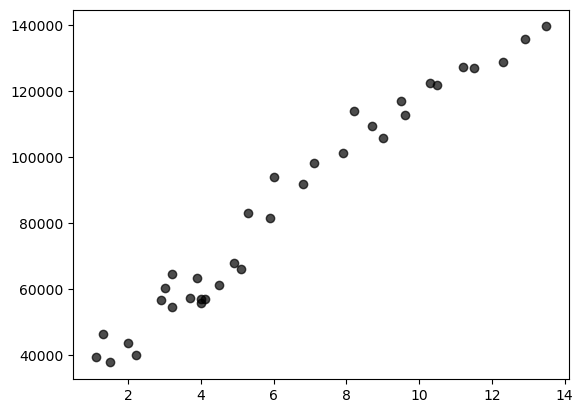

In [ ]:
plt.scatter(Data['YearsExperience'], Data['Salary'], c = 'black', alpha = 0.7)
plt.show()

In [ ]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Salary           35 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes


In [ ]:
#Check if there is duplicate rows
np.sum(Data.duplicated())

np.int64(0)

In [ ]:
# Remove duplicates
#Data.drop_duplicates(inplace=True)

In [ ]:
# Separate the Input Variables & Target Variables
X = Data.iloc[:, :-1]
y = Data.iloc[:, 1]

In [ ]:
print('Type X is: ',type(X))
print('Type y is: ',type(y))

Type X is:  <class 'pandas.core.frame.DataFrame'>
Type y is:  <class 'pandas.core.series.Series'>


In [ ]:
# split data into training set and test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

## Build KNN model for regression

In [ ]:
# Build KNN regressor
KNN = KNeighborsRegressor(n_neighbors=3,weights = 'uniform',metric = 'minkowski',p=2)

# Fit the model on train
KNN.fit(X_train, y_train)

# Predict train data
Train_prediction=KNN.predict(X_train)

In [ ]:
Train_prediction

array([109608.33333333,  44754.66666667,  41093.        , 109608.33333333,
       109608.33333333,  58656.33333333, 131188.66666667, 101274.33333333,
       119894.33333333,  90458.        ,  79710.        ,  57079.        ,
        56610.66666667,  59680.        , 131188.66666667,  41093.        ,
        71776.66666667,  41093.        ,  63682.66666667,  57079.        ,
        56610.66666667,  58733.66666667,  59680.        ,  56610.66666667])

In [ ]:
from sklearn import metrics

print('MAE Train: ', metrics.mean_absolute_error(y_train, Train_prediction))
print('MSE Train: ', metrics.mean_squared_error(y_train, Train_prediction))
print('RMSE Train: ', np.sqrt(metrics.mean_squared_error(y_train, Train_prediction)))
print('MAPE Train: ', metrics.mean_absolute_percentage_error(y_train, Train_prediction))
print('R^2 Train: ', metrics.r2_score(y_train, Train_prediction))

MAE Train:  3368.319444444444
MSE Train:  16257638.763888896
RMSE Train:  4032.0762348805974
MAPE Train:  0.048630750324219964
R^2 Train:  0.9818245386083395


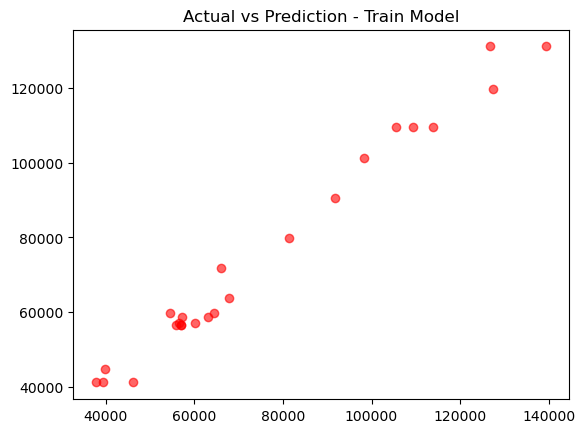

In [ ]:
# How the models was successfuls (Actual vs Prediction plot)

plt.scatter(y_train,Train_prediction,alpha=0.6,color = 'red')
plt.title('Actual vs Prediction - Train Model')
plt.show()

In [ ]:
Train = pd.DataFrame()
Train['YearsExperience'] = X_train
Train['Salary'] = y_train
Train

,YearsExperience,Salary
24,8.7,109431
4,2.2,39891
2,1.5,37731
23,8.2,113812
25,9.0,105582
10,3.9,63218
31,11.5,126756
21,7.1,98273
30,11.2,127345
20,6.8,91738


In [ ]:
#kNN Regression Model different value for K
k = [1, 3, 5, 10, 20, 22]

for i in k:
    #Build kNN regression model for different value of K
    KNN = KNeighborsRegressor(n_neighbors=i,weights = 'uniform',metric = 'minkowski',p=2)

    #Fit the model 
    KNN.fit(X_train, y_train)
    
    #Predict the response in the train
    Train['Prediction K=' + str(i)] = KNN.predict(X_train)

Train.head(10)

,YearsExperience,Salary,Prediction K=1,Prediction K=3,Prediction K=5,Prediction K=10,Prediction K=20,Prediction K=22
24,8.7,109431,109431.0,109608.333333,103767.2,98826.7,82682.65,78694.318182
4,2.2,39891,39891.0,44754.666667,48123.8,51925.9,65883.75,70481.909091
2,1.5,37731,37731.0,41093.000000,43962.4,51925.9,65883.75,70481.909091
23,8.2,113812,113812.0,109608.333333,103767.2,98826.7,82682.65,78694.318182
25,9.0,105582,105582.0,109608.333333,110888.6,98826.7,82682.65,78694.318182
10,3.9,63218,63218.0,58656.333333,58047.8,59385.9,65883.75,70481.909091
31,11.5,126756,126756.0,131188.666667,121715.8,105979.4,82682.65,78694.318182
21,7.1,98273,98273.0,101274.333333,98923.4,84704.1,77703.95,74455.227273
30,11.2,127345,127345.0,119894.333333,121715.8,105979.4,82682.65,78694.318182
20,6.8,91738,91738.0,90458.000000,90243.0,84704.1,77703.95,74455.227273


In [ ]:
# Sort Train dataframe for better visualization
Train.sort_values('YearsExperience', inplace = True)
Train.head(10)

,YearsExperience,Salary,Prediction K=1,Prediction K=3,Prediction K=5,Prediction K=10,Prediction K=20,Prediction K=22
0,1.1,39343,39343.0,41093.000000,43962.4,51925.9,65883.75,70481.909091
1,1.3,46205,46205.0,41093.000000,43962.4,51925.9,65883.75,70481.909091
2,1.5,37731,37731.0,41093.000000,43962.4,51925.9,65883.75,70481.909091
4,2.2,39891,39891.0,44754.666667,48123.8,51925.9,65883.75,70481.909091
5,2.9,56642,56642.0,57079.000000,55114.6,56581.2,65883.75,70481.909091
6,3.0,60150,60150.0,57079.000000,58574.2,56581.2,65883.75,70481.909091
7,3.2,54445,54445.0,59680.000000,58574.2,56581.2,65883.75,70481.909091
8,3.2,64445,54445.0,59680.000000,58574.2,56581.2,65883.75,70481.909091
9,3.7,57189,57189.0,58733.666667,58047.8,59385.9,65883.75,70481.909091
10,3.9,63218,63218.0,58656.333333,58047.8,59385.9,65883.75,70481.909091


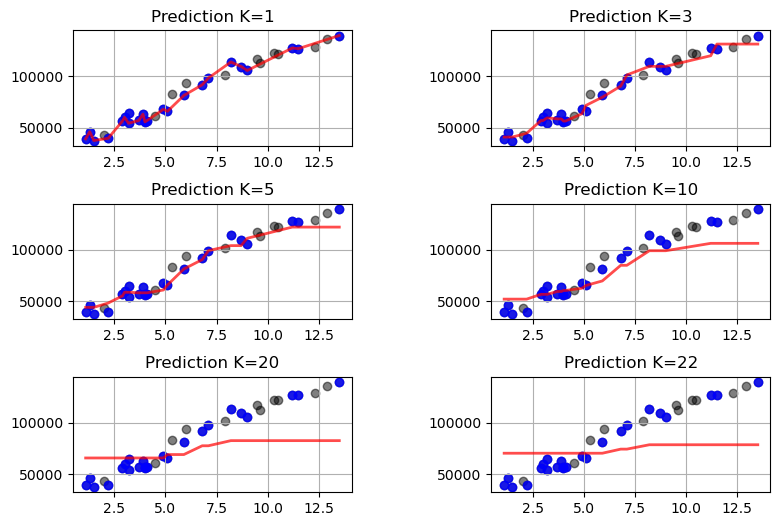

In [ ]:
#Visualization of prediction for different values of K

plt.figure(figsize = (9, 6))
plt.subplots_adjust(hspace = 0.5, wspace = 0.5)

for i in range(1, 7):
    plt.subplot(3, 2, i)
    plt.scatter(Data['YearsExperience'], Data['Salary'], c = 'black', alpha = 0.5)
    plt.scatter(Train['YearsExperience'], Train['Salary'], c = 'blue', alpha = 0.8)
    plt.plot(Train['YearsExperience'], Train.iloc[:, i + 1], c = 'red', linewidth = 2, alpha = 0.7)
    plt.title(Train.columns[i + 1])
    plt.grid()

## Finding the best value for K

## 1- Implementing K-fold cross validation

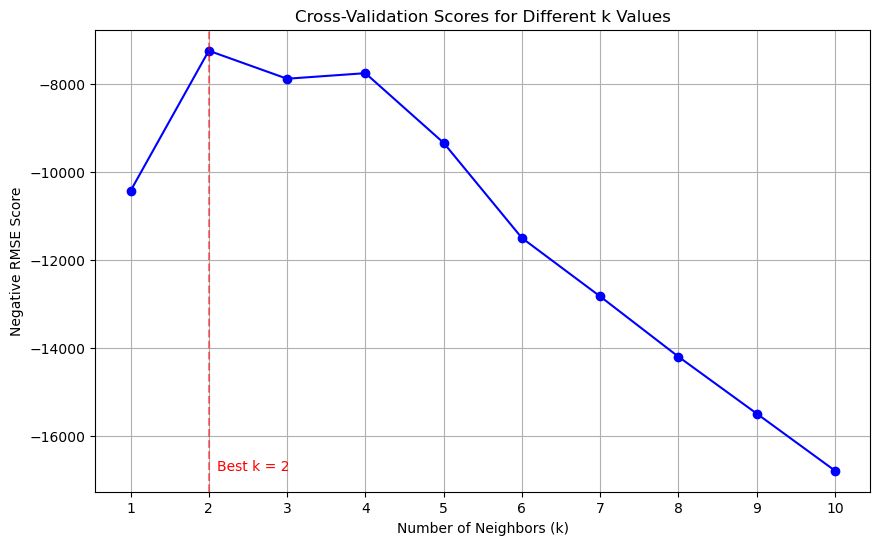

Best k value: 2 with score: -7253.765505634149


In [ ]:
from sklearn.model_selection import cross_val_score

k = list(range(1, 11))  # Example: testing k from 1 to 10

# Initialize dictionary to store CV scores
CV = {}

# Loop through each k value
for i in k:  # Start from 1 instead of 0
    KNN = KNeighborsRegressor(n_neighbors=i, weights='uniform', metric='minkowski', p=2)
    
    # K-fold cross validation
    scores = cross_val_score(estimator=KNN, X=X_train, y=y_train, 
                            scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
    
    # Calculate the average scores and save the results
    CV[i] = scores.mean()

# Convert CV dictionary to lists for plotting
k_values = list(CV.keys())
cv_scores = list(CV.values())

# Plot the CV scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='blue')
plt.title('Cross-Validation Scores for Different k Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Negative RMSE Score')
plt.grid(True)
plt.xticks(k_values)

# Find and mark the best k value
best_k = k_values[np.argmax(cv_scores)]
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.5)
plt.text(best_k+0.1, min(cv_scores), f'Best k = {best_k}', color='red')

plt.show()

print(f"Best k value: {best_k} with score: {CV[best_k]}")

### Final KNN model for k=2

In [ ]:
Test = pd.DataFrame()
Test['YearsExperience'] = X_test
Test['Salary']=y_test
Test

,YearsExperience,Salary
14,4.5,61111
19,6.0,93940
3,2.0,43525
29,10.5,121872
33,12.9,135675
28,10.3,122391
22,7.9,101302
27,9.6,112635
26,9.5,116969
32,12.3,128765


In [ ]:
X_train

,YearsExperience
24,8.7
4,2.2
2,1.5
23,8.2
25,9.0
10,3.9
31,11.5
21,7.1
30,11.2
20,6.8


In [ ]:
# Build KNN regressor
KNN = KNeighborsRegressor(n_neighbors=best_k,weights = 'uniform',metric = 'minkowski',p=2)

# Fit the model on train
KNN.fit(X_train, y_train)

# Predict test data
Test_Prediction=KNN.predict(X_test)

In [ ]:
Test['Best Prediction']=Test_Prediction
Test

,YearsExperience,Salary,Best Prediction
14,4.5,61111,62509.5
19,6.0,93940,86550.5
3,2.0,43525,38811.0
29,10.5,121872,127050.5
33,12.9,135675,133110.5
28,10.3,122391,127050.5
22,7.9,101302,111621.5
27,9.6,112635,107506.5
26,9.5,116969,107506.5
32,12.3,128765,127050.5


In [ ]:
Results = pd.DataFrame({'MSE': metrics.mean_squared_error(y_test, Test['Best Prediction']),
                            'RMSE': np.sqrt(metrics.mean_squared_error(y_test, Test['Best Prediction'])),
                            'MAPE': metrics.mean_absolute_percentage_error(y_test, Test['Best Prediction']) * 100,
                            'MAE' : metrics.mean_absolute_error(y_test, Test['Best Prediction']),
                            'R^2' : metrics.r2_score(y_test, Test['Best Prediction'])},                         
                           index = ['KNN - K-fold'])
Results

,MSE,RMSE,MAPE,MAE,R^2
KNN - K-fold,5.622852e+07,7498.567745,6.770487,6239.454545,0.927341


## 2- Impelemting GridSeachCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range(1, 11)),  # Testing k from 1 to 20
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsRegressor()

model1 = GridSearchCV(knn, param_grid, cv=5)
model1.fit(X_train, y_train)
model1.best_params_

{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}

In [ ]:
model1.best_params_['metric']

'euclidean'

In [ ]:
KNN2 = KNeighborsRegressor(n_neighbors=model1.best_params_['n_neighbors'],
                          metric=model1.best_params_['metric'],
                          weights=model1.best_params_['weights'])

KNN2.fit(X_train, y_train)

Train_prediction=KNN2.predict(X_train)

Test_prediction=KNN2.predict(X_test)

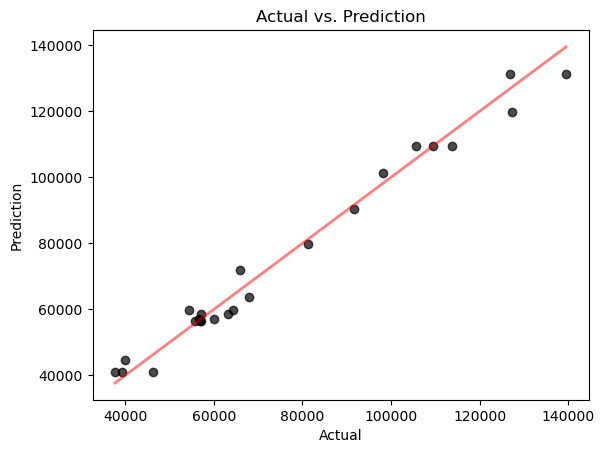

In [ ]:
#Plot actual vs. prediction - Train
plt.scatter(y_train, Train_prediction, c = 'black', alpha = 0.7)
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Prediction')
xp = np.linspace(y_train.min() - 0.2, y_train.max() + 0.2, 100)
plt.plot(xp, xp, c = 'red', linewidth = 2, alpha=0.5)
plt.show()

In [ ]:
print('RMSE = ',np.sqrt(metrics.mean_squared_error(Train_prediction,y_train)))
print('MSE = ',metrics.mean_squared_error(Train_prediction,y_train))
print('MAE = ',metrics.mean_absolute_error(Train_prediction,y_train))
print('R2 = ',metrics.r2_score(Train_prediction,y_train))


RMSE =  4032.0762348805974
MSE =  16257638.763888896
MAE =  3368.319444444444
R2 =  0.9805228292465593


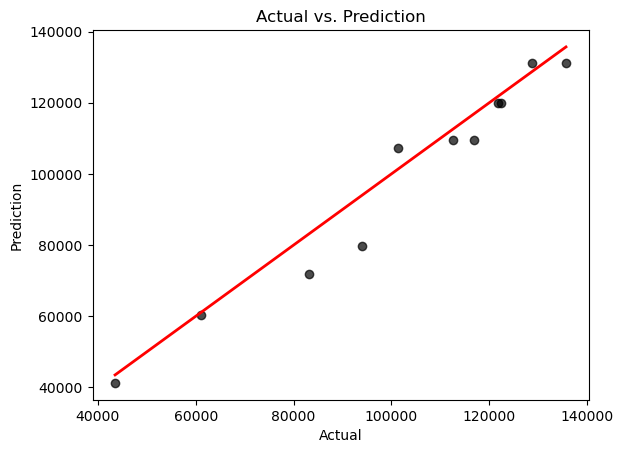

In [ ]:
#Plot actual vs. prediction - Test
plt.scatter(y_test, Test_prediction, c = 'black', alpha = 0.7)
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Prediction')
xp = np.linspace(y_test.min() - 0.2, y_test.max() + 0.2, 100)
plt.plot(xp, xp, c = 'red', linewidth = 2)
plt.show()

# Model evolution

In [ ]:
Results = pd.concat([Results,
                     pd.DataFrame({'MSE': metrics.mean_squared_error(y_test, Test_prediction),
                                  'RMSE': np.sqrt(metrics.mean_squared_error(y_test, Test_prediction)),
                                  'MAPE': metrics.mean_absolute_percentage_error(y_test, Test_prediction) * 100,
                                  'MAE': metrics.mean_absolute_error(y_test, Test_prediction),
                                  'R^2': metrics.r2_score(y_test, Test_prediction)},
                                 index=['KNN - GridSearch'])
                    ])  # Added closing parenthesis here to complete pd.concat() function call
Results

,MSE,RMSE,MAPE,MAE,R^2
KNN - K-fold,5.622852e+07,7498.567745,6.770487,6239.454545,0.927341
KNN - GridSearch,4.274065e+07,6537.633321,5.357292,5115.666667,0.944770
